In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Загружаем данные Netflix
df = pd.read_csv('/Users/igorsotikov/Downloads/netflix1.csv')

# Смотрим первые 5 строк
df.head()

,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,United States,9/25/2021,2020,PG-13,90 min,Documentaries
1,s3,TV Show,Ganglands,Julien Leclercq,France,9/24/2021,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act..."
2,s6,TV Show,Midnight Mass,Mike Flanagan,United States,9/24/2021,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries"
3,s14,Movie,Confessions of an Invisible Girl,Bruno Garotti,Brazil,9/22/2021,2021,TV-PG,91 min,"Children & Family Movies, Comedies"
4,s8,Movie,Sankofa,Haile Gerima,United States,9/24/2021,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies"


In [40]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8790 entries, 0 to 8789
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8790 non-null   str  
 1   type          8790 non-null   str  
 2   title         8790 non-null   str  
 3   director      8790 non-null   str  
 4   country       8790 non-null   str  
 5   date_added    8790 non-null   str  
 6   release_year  8790 non-null   int64
 7   rating        8790 non-null   str  
 8   duration      8790 non-null   str  
 9   listed_in     8790 non-null   str  
dtypes: int64(1), str(9)
memory usage: 686.8 KB


In [41]:
df.tail()

,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in
8785,s8797,TV Show,Yunus Emre,Not Given,Turkey,1/17/2017,2016,TV-PG,2 Seasons,"International TV Shows, TV Dramas"
8786,s8798,TV Show,Zak Storm,Not Given,United States,9/13/2018,2016,TV-Y7,3 Seasons,Kids' TV
8787,s8801,TV Show,Zindagi Gulzar Hai,Not Given,Pakistan,12/15/2016,2012,TV-PG,1 Season,"International TV Shows, Romantic TV Shows, TV ..."
8788,s8784,TV Show,Yoko,Not Given,Pakistan,6/23/2018,2016,TV-Y,1 Season,Kids' TV
8789,s8786,TV Show,YOM,Not Given,Pakistan,6/7/2018,2016,TV-Y7,1 Season,Kids' TV


In [42]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8790 entries, 0 to 8789
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8790 non-null   str  
 1   type          8790 non-null   str  
 2   title         8790 non-null   str  
 3   director      8790 non-null   str  
 4   country       8790 non-null   str  
 5   date_added    8790 non-null   str  
 6   release_year  8790 non-null   int64
 7   rating        8790 non-null   str  
 8   duration      8790 non-null   str  
 9   listed_in     8790 non-null   str  
dtypes: int64(1), str(9)
memory usage: 686.8 KB


In [43]:
df.describe()

,release_year
count,8790.000000
mean,2014.183163
std,8.825466
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [44]:
df.describe(include=['object', 'string'])

,show_id,type,title,director,country,date_added,rating,duration,listed_in
count,8790,8790,8790,8790,8790,8790,8790,8790,8790
unique,8790,2,8787,4528,86,1713,14,220,513
top,s1,Movie,9-Feb,Not Given,United States,1/1/2020,TV-MA,1 Season,"Dramas, International Movies"
freq,1,6126,2,2588,3240,110,3205,1791,362


In [45]:
## Data cleaning 

In [46]:
df.isna().sum()

show_id         0
type            0
title           0
director        0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
dtype: int64

In [47]:
df.duplicated().sum()

np.int64(0)

In [48]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in'],
      dtype='str')

In [49]:
df.rename(columns={'date_added':'Date'},inplace=True)

In [50]:
df['Date']=pd.to_datetime(df['Date'])

In [51]:
## Data Visualization

In [52]:
## Distribution of Content Type

/var/folders/md/9390rkwj10x8hl59w4j2l8yw0000gn/T/ipykernel_18947/2580021694.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='type', palette='Set2')


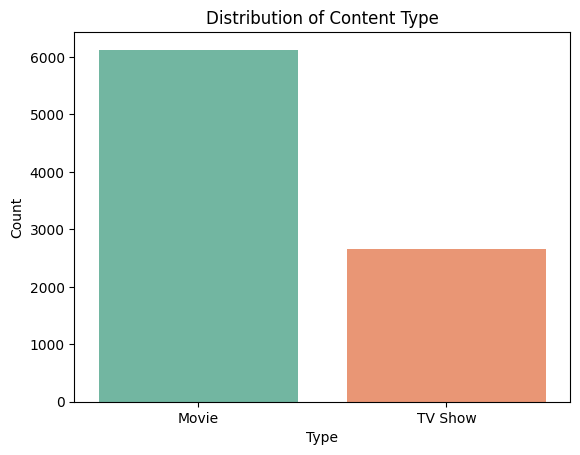

In [53]:
sns.countplot(data=df, x='type', palette='Set2')
plt.title('Distribution of Content Type')
plt.xlabel('Type')
plt.ylabel('Count')
plt.show()

In [54]:
## Content Added Over Time

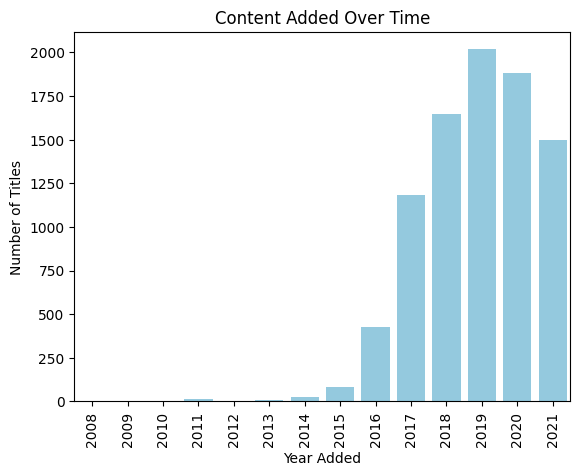

In [55]:
df['year_added'] = df['Date'].dt.year

sns.countplot(data=df, x='year_added', color='skyblue')
plt.xticks(rotation=90)
plt.title('Content Added Over Time')
plt.xlabel('Year Added')
plt.ylabel('Number of Titles')
plt.show()

In [56]:
## Movies vs TV Shows Over Time

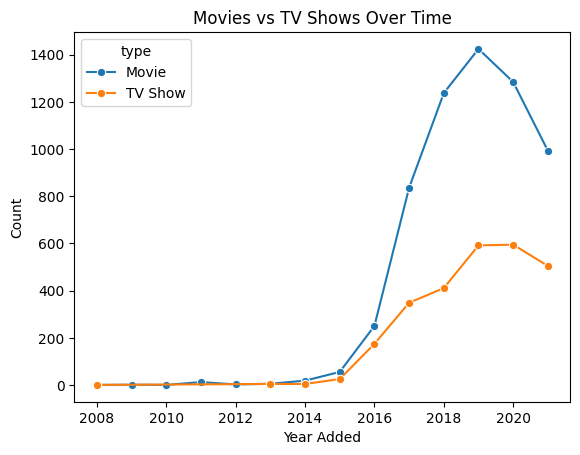

In [57]:
year_type = df.groupby(['year_added', 'type']).size().reset_index(name='count')

sns.lineplot(
    data=year_type,
    x='year_added',
    y='count',
    hue='type',
    marker='o'
)

plt.title('Movies vs TV Shows Over Time')
plt.xlabel('Year Added')
plt.ylabel('Count')
plt.show()

In [58]:
## Release Year Distribution

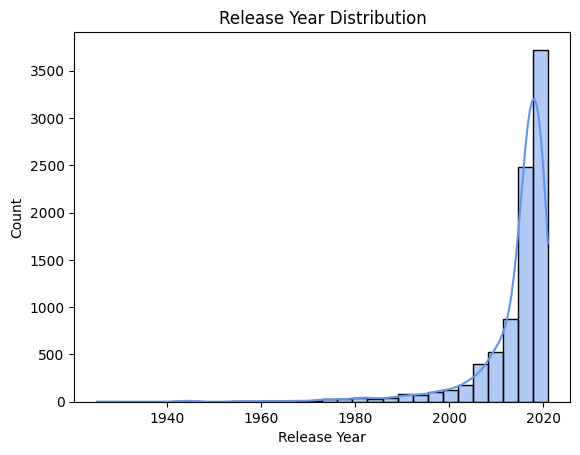

In [59]:
sns.histplot(df['release_year'], bins=30, kde=True, color='cornflowerblue')
plt.title('Release Year Distribution')
plt.xlabel('Release Year')
plt.ylabel('Count')
plt.show()

In [60]:
## Top 10 Countries by Content

/var/folders/md/9390rkwj10x8hl59w4j2l8yw0000gn/T/ipykernel_18947/231995024.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


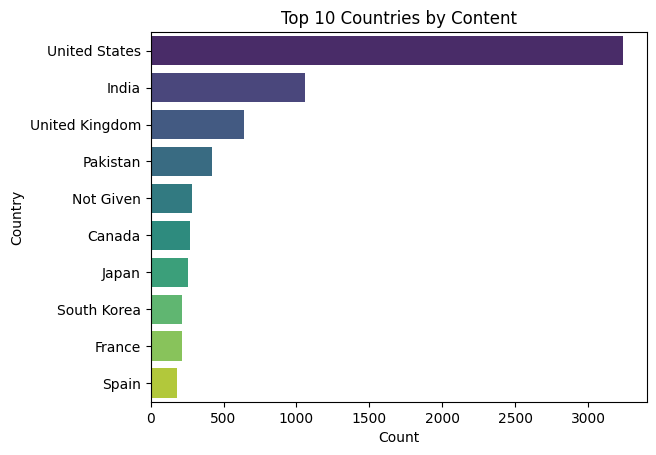

In [61]:
top_countries = df['country'].value_counts().head(10)

sns.barplot(
    x=top_countries.values,
    y=top_countries.index,
    palette='viridis'
)

plt.title('Top 10 Countries by Content')
plt.xlabel('Count')
plt.ylabel('Country')
plt.show()

In [62]:
## Content Rating Distribution

/var/folders/md/9390rkwj10x8hl59w4j2l8yw0000gn/T/ipykernel_18947/424563895.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


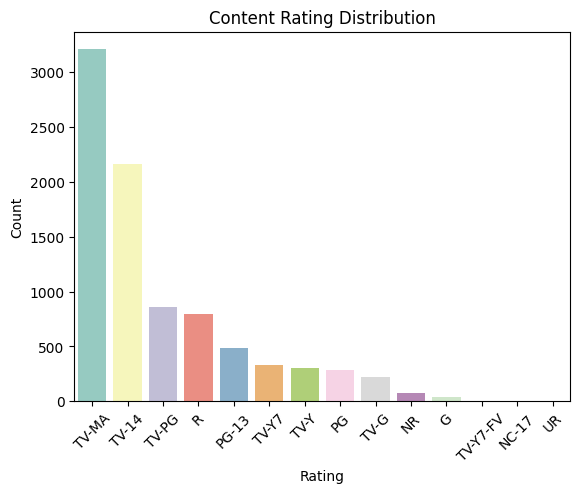

In [63]:
sns.countplot(
    data=df,
    x='rating',
    order=df['rating'].value_counts().index,
    palette='Set3'
)

plt.title('Content Rating Distribution')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

In [64]:
## Rating vs Content Type

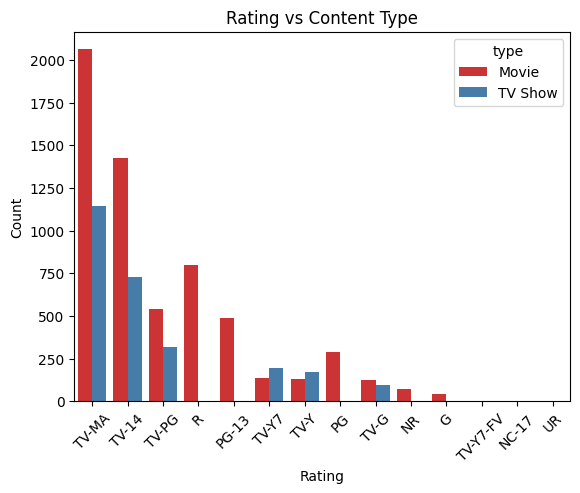

In [65]:
sns.countplot(
    data=df,
    x='rating',
    hue='type',
    order=df['rating'].value_counts().index,
    palette='Set1'
)

plt.title('Rating vs Content Type')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

In [66]:
## Movie Duration Distribution

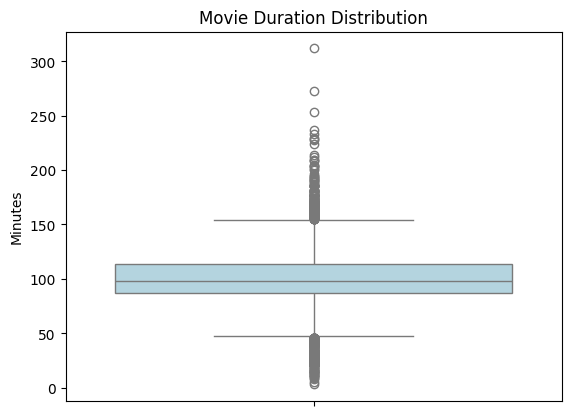

In [67]:
movies = df[df['type'] == 'Movie'].copy()
movies['duration_min'] = movies['duration'].str.replace(' min', '').astype(int)

sns.boxplot(y=movies['duration_min'], color='lightblue')
plt.title('Movie Duration Distribution')
plt.ylabel('Minutes')
plt.show()

In [68]:
## Number of Seasons for TV Shows

/var/folders/md/9390rkwj10x8hl59w4j2l8yw0000gn/T/ipykernel_18947/10895006.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


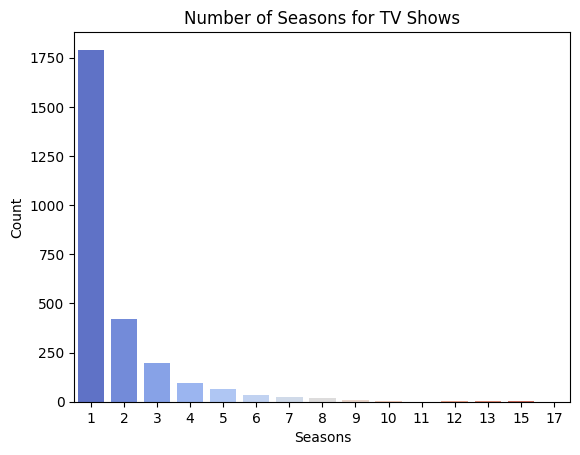

In [69]:
tv = df[df['type'] == 'TV Show'].copy()
tv['seasons'] = tv['duration'] \
    .str.replace(' Seasons', '') \
    .str.replace(' Season', '') \
    .astype(int)

sns.countplot(
    data=tv,
    x='seasons',
    palette='coolwarm'
)

plt.title('Number of Seasons for TV Shows')
plt.xlabel('Seasons')
plt.ylabel('Count')
plt.show()

In [70]:
## Top 10 Genres on Netflix

/var/folders/md/9390rkwj10x8hl59w4j2l8yw0000gn/T/ipykernel_18947/2376464654.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


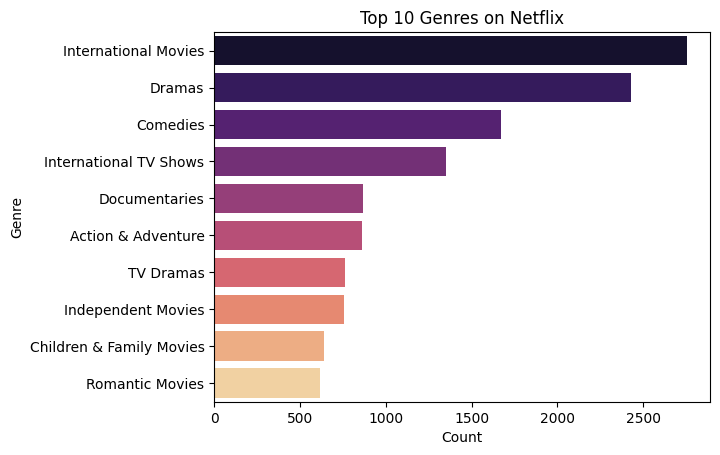

In [71]:
df['listed_in'] = df['listed_in'].str.split(', ')
genres = df.explode('listed_in')

top_genres = genres['listed_in'].value_counts().head(10)

sns.barplot(
    x=top_genres.values,
    y=top_genres.index,
    palette='magma'
)

plt.title('Top 10 Genres on Netflix')
plt.xlabel('Count')
plt.ylabel('Genre')
plt.show()

In [72]:
## Top 10 Directors

/var/folders/md/9390rkwj10x8hl59w4j2l8yw0000gn/T/ipykernel_18947/1352343072.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


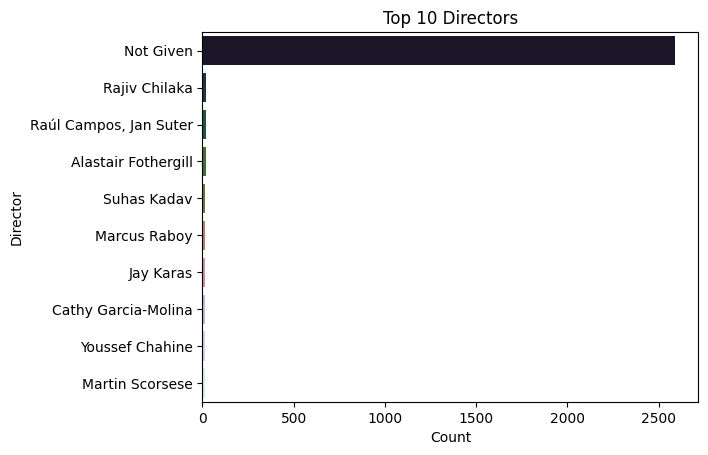

In [73]:
top_directors = df['director'].value_counts().head(10)

sns.barplot(
    x=top_directors.values,
    y=top_directors.index,
    palette='cubehelix'
)

plt.title('Top 10 Directors')
plt.xlabel('Count')
plt.ylabel('Director')
plt.show()